# 🛰️ 데이터 원천: MODIS (Terra/Aqua 위성)

NASA의 MODIS 센서는 전 지구 식생 모니터링의 글로벌 표준입니다.
- **공간 해상도** : 250m (온도는 1km)
- **시간 해상도** : 16일 주기(온도는 8일 주기) → 구름 제거 후 **월별 합성 (Monthly Composite)** 가공
- **업데이트 주기** : 실시간 (Near Real-Time; 약 2~3일 내외)
- **평년 기간** : 2003년 ~ 2022년 (20년; MODIS 데이터의 신뢰성이 높은 구간을 평년 기준으로 설정)

# 🌿 식생 지수(Vegetation Indices) 핵심 설명

## 1. NDVI & EVI (현재 상태의 푸르름)

가장 기초적인 지표로, 식물이 얼마나 싱싱한지를 나타냅니다.

* **NDVI (Normalized Difference Vegetation Index):** 식물의 엽록소가 반사하는 빛을 측정합니다. 1에 가까울수록 울창하고, 0에 가까우면 메마른 땅입니다.
$$NDVI = \frac{NIR - RED}{NIR + RED}$$

* **EVI (Enhanced Vegetation Index):** NDVI의 단점인 대기 노이즈와 빽빽한 숲에서의 수치 포화 현상을 보정한 지수입니다. 동아프리카의 우기(Rainy Season) 분석에 더 정밀한 값을 제공합니다.

## 2. VCI (Vegetation Condition Index, 식생 상태 지수)

과거 이맘때와 비교해서 얼마나 푸른가를 보여줍니다.

* **산출 방식:** 현재 NDVI가 과거 20년 동안의 최솟값(Min)과 최댓값(Max) 사이에서 어느 위치에 있는지 0~100으로 표현합니다.
* **해석:** **30 이하**면 과거 기록에 비추어 볼 때 심각한 식생 가뭄이 발생한 것으로 간주합니다.

## 3. VHI (Vegetation Health Index, 식생 건강 지수) - **최종 지표**

식생(VCI)과 온도(TCI) 스트레스를 5:5로 결합한 **종합 가뭄 지수**입니다.
$$VHI = 0.5 \times VCI + 0.5 \times TCI$$

* **특징:** 단순히 풀이 마른 것뿐만 아니라, 지면 온도(LST)가 비정상적으로 높아 식물이 열 스트레스를 받는 상황까지 반영합니다.
* **용도:** **가뭄으로 인한 작물 수확량 감소**를 예측할 때 가장 상관관계가 높은 '끝판왕' 변수입니다.

In [1]:
import ee

# ⚠️ 중요: 아래에 사용 중인 Google Cloud Project ID를 입력해야 합니다.
# GEE Code Editor (https://code.earthengine.google.com/) 우측 상단 등에서 확인 가능합니다.
project_id = 'wfp-project-486106'

# GEE 인증 및 초기화
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

In [2]:
# ==========================================
# 🚀 사용자 설정
# ==========================================
# 동아프리카 ROI (Region of Interest)
ROI = ee.Geometry.Rectangle([25, -15, 52, 22])

# 분석 기간 (2007 ~ 2025)
TARGET_START = '2007-01-01'
TARGET_END = '2025-12-31'

# 평년 기준 (Historical Baseline for VCI/TCI)
# MODIS 데이터가 안정적인 2003년부터 2022년까지를 평년으로 설정
REF_START = '2003-01-01'
REF_END = '2022-12-31'

EXPORT_DESC = 'EastAfrica_Vegetation_Indices'

# [중요] 해상도 설정 (단위: 미터)
# - 원본 NDVI는 250m이지만, LST(온도)가 1km입니다.
# - VHI 계산을 위해 1000m로 맞추는 것이 물리적으로 타당하며 용량 관리에도 좋습니다.
# 1km (1000) -> 5.5km (5566) 변경
# CHIRPS 강수량 데이터와 격자 크기를 맞추고, 용량을 1/25로 줄입니다.
RESOLUTION = 5566
# ==========================================

In [3]:
# 2. 데이터셋 로드 및 전처리 함수

# (1) MODIS NDVI/EVI (MOD13Q1: 16일 주기, 250m)
def load_ndvi(img):
    # Scale Factor: 0.0001
    return img.select(['NDVI', 'EVI']).multiply(0.0001).copyProperties(img, ['system:time_start'])

modis_vi = ee.ImageCollection("MODIS/061/MOD13Q1").map(load_ndvi)

# (2) MODIS LST (MOD11A2: 8일 주기, 1km)
def load_lst(img):
    # Scale Factor: 0.02, Kelvin -> Celsius 변환
    lst = img.select('LST_Day_1km').multiply(0.02).subtract(273.15).rename('LST')
    return lst.copyProperties(img, ['system:time_start'])

modis_lst = ee.ImageCollection("MODIS/061/MOD11A2").map(load_lst)

In [4]:
# 3. 월별 합성 (Monthly Composite) 함수
# - NDVI/EVI: 구름 영향을 피하기 위해 최대값 합성 (Max Composite) 권장
# - LST: 평균값 합성 (Mean Composite)
def create_monthly_composite(start_date, end_date):
    n_months = ee.Date(end_date).difference(ee.Date(start_date), 'month').round()

    def make_monthly(n):
        date = ee.Date(start_date).advance(n, 'month')
        next_date = date.advance(1, 'month')

        # NDVI/EVI: Max Composite
        vi_mon = modis_vi.filterDate(date, next_date).max()

        # LST: Mean Composite
        lst_mon = modis_lst.filterDate(date, next_date).mean()

        # 병합
        return vi_mon.addBands(lst_mon).set('system:time_start', date.millis()).set('month', date.get('month'))

    return ee.ImageCollection(ee.List.sequence(0, n_months.subtract(1)).map(make_monthly))

In [5]:
# 4. 평년값(Climatology Min/Max) 계산 (2003-2022)
# VCI, TCI 계산을 위해 월별 절대 최대/최소값이 필요합니다.

ref_col = create_monthly_composite(REF_START, REF_END)

monthly_stats = []
for m in range(1, 13):
    m_col = ref_col.filter(ee.Filter.eq('month', m))

    # NDVI Min/Max
    ndvi_min = m_col.select('NDVI').min().rename('NDVI_min')
    ndvi_max = m_col.select('NDVI').max().rename('NDVI_max')

    # LST Min/Max
    lst_min = m_col.select('LST').min().rename('LST_min')
    lst_max = m_col.select('LST').max().rename('LST_max')

    stats = ndvi_min.addBands(ndvi_max).addBands(lst_min).addBands(lst_max).set('month', m)
    monthly_stats.append(stats)

ee_monthly_stats = ee.List(monthly_stats)

In [6]:
# 5. 타겟 기간 지수 산출 (VCI, TCI, VHI)
target_col = create_monthly_composite(TARGET_START, TARGET_END)

def calculate_indices(img):
    m = img.date().get('month')
    stats = ee.Image(ee_monthly_stats.get(m.subtract(1)))

    # 변수 추출
    ndvi = img.select('NDVI')
    lst = img.select('LST')

    ndvi_min = stats.select('NDVI_min')
    ndvi_max = stats.select('NDVI_max')
    lst_min = stats.select('LST_min')
    lst_max = stats.select('LST_max')

    # (1) VCI (Vegetation Condition Index)
    # 공식: 100 * (NDVI - Min) / (Max - Min)
    vci = ndvi.subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100).rename('VCI')

    # (2) TCI (Temperature Condition Index)
    # 공식: 100 * (Max - LST) / (Max - Min) -> 온도는 낮을수록 좋음(식생 입장에서)
    tci = lst_max.subtract(lst).divide(lst_max.subtract(lst_min)).multiply(100).rename('TCI')

    # (3) VHI (Vegetation Health Index)
    # 공식: 0.5 * VCI + 0.5 * TCI
    vhi = vci.multiply(0.5).add(tci.multiply(0.5)).rename('VHI')

    # 모든 밴드 합치기 (NDVI, EVI, LST, VCI, TCI, VHI)
    return img.addBands([vci, tci, vhi]).copyProperties(img, ['system:time_start'])

final_col = target_col.map(calculate_indices)

In [7]:
# 6. 연도별 내보내기 (Export) 수정
years = list(range(2007, 2026))
print(f"총 {len(years)}개 연도 파일 Export 시작 (해상도: {RESOLUTION}m)")

for y in years:
    start_dt = f'{y}-01-01'
    end_dt = f'{y}-12-31'

    # 해당 연도 필터링
    year_col = final_col.filterDate(start_dt, ee.Date(end_dt).advance(1, 'day'))

    # 데이터 유무 확인
    if year_col.size().getInfo() == 0:
        continue

    desc_str = f"{EXPORT_DESC}_{y}_5km" # 파일명에 5km 표시

    # 내보내기 설정
    task = ee.batch.Export.image.toDrive(
        image=year_col.toBands(),
        description=desc_str,
        folder='GEE_Vegetation_Exports_5km',
        region=ROI,
        scale=RESOLUTION, # 5566m 적용
        crs='EPSG:4326',
        fileFormat='GeoTIFF',
        maxPixels=1e13,
        fileDimensions=[2048, 2048]
    )
    task.start()
    print(f"  Running: {y}년 데이터 Export 요청 완료")

print("\n🚀 해상도 최적화(5km) 작업 요청 완료!")

총 19개 연도 파일 Export 시작 (해상도: 5566m)
  Running: 2007년 데이터 Export 요청 완료
  Running: 2008년 데이터 Export 요청 완료
  Running: 2009년 데이터 Export 요청 완료
  Running: 2010년 데이터 Export 요청 완료
  Running: 2011년 데이터 Export 요청 완료
  Running: 2012년 데이터 Export 요청 완료
  Running: 2013년 데이터 Export 요청 완료
  Running: 2014년 데이터 Export 요청 완료
  Running: 2015년 데이터 Export 요청 완료
  Running: 2016년 데이터 Export 요청 완료
  Running: 2017년 데이터 Export 요청 완료
  Running: 2018년 데이터 Export 요청 완료
  Running: 2019년 데이터 Export 요청 완료
  Running: 2020년 데이터 Export 요청 완료
  Running: 2021년 데이터 Export 요청 완료
  Running: 2022년 데이터 Export 요청 완료
  Running: 2023년 데이터 Export 요청 완료
  Running: 2024년 데이터 Export 요청 완료
  Running: 2025년 데이터 Export 요청 완료

🚀 해상도 최적화(5km) 작업 요청 완료!


In [15]:
# 최근 19개의 작업 상태 확인
tasks = ee.batch.Task.list()

print("=== GEE 작업 목록 (최근 19개) ===")
for task in tasks[:19]:
    # 작업 설명, 상태, ID 출력
    print(f"[{task.config['description']}] : {task.state}")

    # 만약 에러가 났다면 에러 메시지 출력
    if task.state == 'FAILED':
        print(f"  ❌ 에러 원인: {task.status()['error_message']}")

=== GEE 작업 목록 (최근 19개) ===
[EastAfrica_Vegetation_Indices_2025_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2024_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2023_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2022_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2021_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2020_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2019_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2018_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2017_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2016_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2015_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2014_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2013_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2012_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2011_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2010_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2009_5km] : COMPLETED
[EastAfrica_Vegetation_Indices_2008_5km] : COMPLETED
[EastAfrica_Vegetat

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import glob
import xarray as xr
import rioxarray
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 사용자 설정: 파일 경로
# ==========================================
# GEE 코드에서 설정한 폴더명
base_path = '/content/drive/MyDrive/GEE_Vegetation_Exports_5km'

# 검증할 연도 (파일이 가장 먼저 생겼을 2007년 추천)
target_year = 2007

In [3]:
# ==========================================
# 2. 파일 존재 여부 및 리스트 확인
# ==========================================
print(f"📂 작업 폴더: {base_path}")

if not os.path.exists(base_path):
    print("❌ 폴더를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # 5km 파일 패턴 검색
    file_pattern = os.path.join(base_path, f"*_{target_year}_5km*.tif")
    files = glob.glob(file_pattern)

    if not files:
        print(f"⚠️ {target_year}년 파일을 찾을 수 없습니다. (아직 다운로드 중일 수 있음)")
        # 다른 연도라도 있는지 확인
        all_files = glob.glob(os.path.join(base_path, "*.tif"))
        if all_files:
            print(f"   대신 발견된 파일들: {[os.path.basename(f) for f in all_files[:3]]} ...")
            target_file = all_files[0] # 첫 번째 파일로 대체 테스트
        else:
            target_file = None
    else:
        target_file = files[0]
        print(f"✅ 검증 대상 파일 발견: {os.path.basename(target_file)}")

📂 작업 폴더: /content/drive/MyDrive/GEE_Vegetation_Exports_5km
✅ 검증 대상 파일 발견: EastAfrica_Vegetation_Indices_2007_5km.tif


In [5]:
# ==========================================
# 3. 데이터 정밀 검증 (xarray 사용)
# ==========================================

# 엔진을 rasterio로 설정하여 GeoTIFF 로드
ds = xr.open_dataset(target_file, engine='rasterio')

# [수정 핵심] 차원 순서 강제 변경 (Band, Y, X 순서로 맞춤)
# 만약 현재 순서가 다르다면 transpose를 수행합니다.
if ds.band_data.dims != ('band', 'y', 'x'):
    print(f"⚠️ 차원 순서 변경 중: {ds.band_data.dims} -> ('band', 'y', 'x')")
    ds['band_data'] = ds.band_data.transpose('band', 'y', 'x')

# 데이터 객체 재정의 (편의상)
data = ds.band_data

print("\n--- [1] 기본 메타데이터 확인 ---")
print(f"Dimensions: {data.dims}")
print(f"Shape: {data.shape}") # (밴드수, 세로, 가로) 확인

# 해상도 확인
# rioxarray가 transpose 후에도 메타데이터를 잘 못 읽을 경우를 대비해 예외처리
try:
    res = data.rio.resolution()
    print(f"Resolution: {res[0]:.5f} (약 0.05면 5km 정상)")
except:
    print("Resolution 정보를 메타데이터에서 바로 읽지 못했습니다 (좌표계 확인 필요)")

# 밴드 개수 확인
num_bands = data.shape[0] # Transpose를 했으므로 첫 번째 차원이 밴드 수
print(f"Total Bands: {num_bands}개 (예상: 72개)")

# 밴드 이름 확인 (GEE Export 시 이름이 변경되었을 수 있음)
# long_name 속성을 보거나 밴드 인덱스 확인
print(f"밴드 속성 예시: {data.attrs.get('long_name', '속성 없음')[:2]}")


--- [1] 기본 메타데이터 확인 ---
Dimensions: ('band', 'y', 'x')
Shape: (72, 761, 541)
Resolution: 0.05000 (약 0.05면 5km 정상)
Total Bands: 72개 (예상: 72개)
밴드 속성 예시: ('0_NDVI', '0_EVI')


In [12]:
# ==========================================
# 4. 변수별 값의 범위(Range) 체크
# ==========================================
print("\n--- [2] 주요 변수 통계값 검증 (Sample) ---")

# 밴드 순서는 보통 [1월_NDVI, 1월_EVI, ..., 1월_VHI, 2월_NDVI...] 순서일 가능성 높음
# 혹은 변수별로 [1월_NDVI, 2월_NDVI...] 일 수도 있음.
# 일단 첫 번째 밴드(Band 1)와 마지막 밴드를 샘플링

def check_stats(band_idx, label):
    # xarray data selection
    band_vals = data[band_idx].values

    # 유효 데이터 필터링 (0과 NaN 제외)
    valid_data = band_vals[~np.isnan(band_vals) & (band_vals != 0)]

    if len(valid_data) == 0:
        print(f"⚠️ {label}: 유효한 데이터가 없습니다.")
        return

    band_nm = data.attrs.get('long_name')[band_idx]
    mn, mx, mean = valid_data.min(), valid_data.max(), valid_data.mean()
    print(f"[{label} = {band_nm}] Min: {mn:.2f}, Max: {mx:.2f}, Mean: {mean:.2f}")

# 첫 번째 밴드 확인
check_stats(0, "Band 1 (First)")
# 마지막 밴드 확인
check_stats(num_bands - 1, f"Band {num_bands} (Last)")


--- [2] 주요 변수 통계값 검증 (Sample) ---
[Band 1 (First) = 0_NDVI] Min: -0.20, Max: 0.95, Mean: 0.41
[Band 72 (Last) = 11_VHI] Min: 0.00, Max: 100.00, Mean: 44.39



--- [3] 지도 시각화 ---


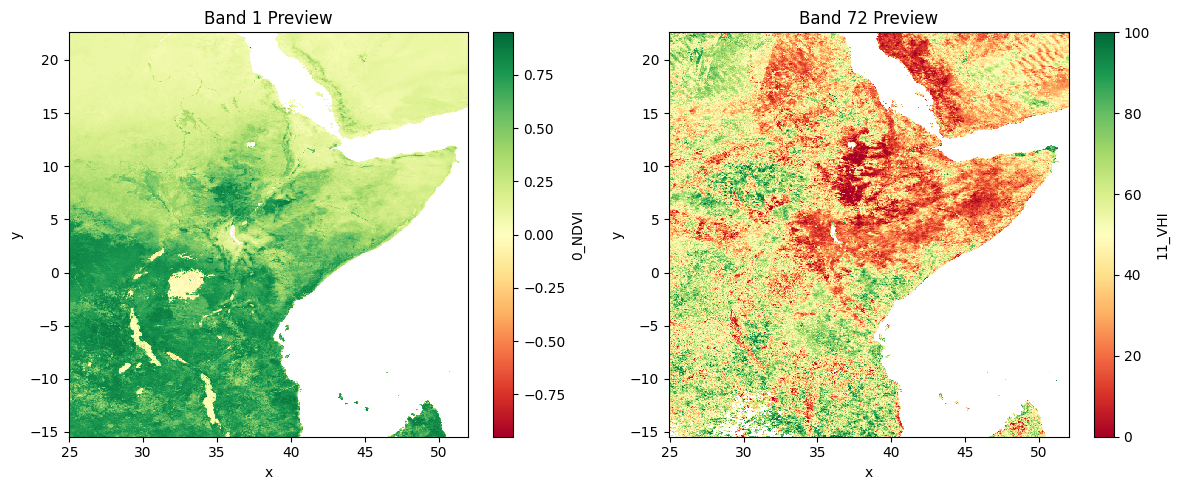


✅ 검증 완료!


In [14]:
# ==========================================
# 5. 지도 시각화
# ==========================================
print("\n--- [3] 지도 시각화 ---")
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
sp1 = data[0]
sp1.attrs['long_name'] = data.attrs.get('long_name')[0]
sp1.plot(cmap='RdYlGn', ax=ax1)
ax1.set_title("Band 1 Preview")

ax2 = plt.subplot(1, 2, 2)
sp2 = data[-1]
sp2.attrs['long_name'] = data.attrs.get('long_name')[-1]
sp2.plot(cmap='RdYlGn', ax=ax2)
ax2.set_title(f"Band {num_bands} Preview")

plt.tight_layout()
plt.show()

print("\n✅ 검증 완료!")